[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/content/00_transformer_at_inference_time/00.3_attention_and_kv_cache/lab.ipynb)
[![Open In Molab](https://img.shields.io/badge/Open%20in-Molab-blue)](https://molab.marimo.io/github/harshuljain13/llm-inference-at-scale/blob/master/content/00_transformer_at_inference_time/00.3_attention_and_kv_cache/lab.ipynb)

# Lab 0.3: Attention Mechanism and the KV Cache

This lab implements the attention mechanism **with and without KV cache** and measures the difference.
You will see exactly why caching K and V projections is essential for efficient autoregressive generation.

**What you'll observe:**
- Without cache: each decode step recomputes K,V for ALL previous tokens (time grows linearly)
- With cache: each decode step only computes K,V for the NEW token (time stays constant)
- The memory cost of maintaining this cache

In [ ]:
# ── INSTALL (run once, then skip on subsequent runs) ─────────────────────────
import subprocess, sys

def pip_install(*packages, extra_args=None):
    """Install packages via pip. Pass extra_args=['--no-build-isolation'] if needed."""
    cmd = [sys.executable, '-m', 'pip', 'install', '-q'] + list(packages)
    if extra_args:
        cmd += extra_args
    subprocess.check_call(cmd)

pip_install('torch', 'matplotlib', 'numpy', 'tqdm')
# ─────────────────────────────────────────────────────────────────────────────

In [8]:
# Install dependencies (quiet mode)

import torch               # Tensor operations and linear algebra
import torch.nn.functional as F  # Softmax for attention scores
import matplotlib.pyplot as plt  # Visualization
import numpy as np         # Numerical utilities
import time                # Wall-clock timing
from tqdm import tqdm      # Progress bars

# Reproducibility
torch.manual_seed(42)

# Use GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## Implementing Attention Without Cache

In standard (naive) autoregressive generation, at each decode step we:
1. Take the query from the current token
2. Recompute K and V projections for **ALL** previous tokens from scratch
3. Compute attention scores and weighted sum

This means at step N, we do O(N) work, even though we already computed K,V for tokens 1..N-1 in the previous step.

In [9]:
def attention_no_cache(query_hidden, all_hidden_states, W_K, W_V, W_O):
    """
    Naive attention: recomputes K,V for ALL tokens every single step.
    
    Args:
        query_hidden: [1, d] - hidden state of current token
        all_hidden_states: [N, d] - hidden states of ALL tokens so far
        W_K: [d, d] - key projection weights
        W_V: [d, d] - value projection weights
        W_O: [d, d] - output projection weights
    Returns:
        output: [1, d] - attention output for current token
    """
    d = query_hidden.shape[-1]
    
    # Project current token to query
    # Shape: [1, d] @ [d, d] = [1, d]
    Q = query_hidden @ W_K  # Using W_K as W_Q for simplicity
    
    # WASTEFUL: Recompute K for ALL N tokens from scratch
    # Even tokens 1..N-1 that we already computed last step
    # Shape: [N, d] @ [d, d] = [N, d]
    K = all_hidden_states @ W_K
    
    # WASTEFUL: Recompute V for ALL N tokens from scratch
    # Shape: [N, d] @ [d, d] = [N, d]
    V = all_hidden_states @ W_V
    
    # Compute attention scores: Q @ K^T / sqrt(d)
    # Shape: [1, d] @ [d, N] = [1, N]
    scores = (Q @ K.T) / (d ** 0.5)
    
    # Softmax to get attention weights
    # Shape: [1, N]
    weights = F.softmax(scores, dim=-1)
    
    # Weighted sum of values
    # Shape: [1, N] @ [N, d] = [1, d]
    attn_output = weights @ V
    
    # Output projection
    # Shape: [1, d] @ [d, d] = [1, d]
    output = attn_output @ W_O
    
    return output

print('attention_no_cache defined: recomputes K,V for all N tokens every step')

attention_no_cache defined: recomputes K,V for all N tokens every step


## Implementing Attention With Cache

The KV cache stores previously computed K and V projections. At each decode step:
1. Compute K,V **only for the new token** (1 vector, not N)
2. Concatenate with the cached K,V from previous steps
3. Compute attention using the full (cached + new) K,V

This reduces per-step compute from O(N) matrix multiplications to O(1) for projection, though attention scoring is still O(N).

In [10]:
def attention_with_cache(query_hidden, new_hidden, W_K, W_V, W_O, cached_K, cached_V):
    """
    Cached attention: only computes K,V for the NEW token.
    
    Args:
        query_hidden: [1, d] - hidden state of current token (for Q)
        new_hidden: [1, d] - hidden state of new token (for K,V)
        W_K: [d, d] - key projection weights
        W_V: [d, d] - value projection weights  
        W_O: [d, d] - output projection weights
        cached_K: [N-1, d] - previously computed keys
        cached_V: [N-1, d] - previously computed values
    Returns:
        output: [1, d]
        new_cached_K: [N, d] - updated key cache
        new_cached_V: [N, d] - updated value cache
    """
    d = query_hidden.shape[-1]
    
    # Project current token to query
    # Shape: [1, d] @ [d, d] = [1, d]
    Q = query_hidden @ W_K
    
    # EFFICIENT: Only compute K,V for the ONE new token
    # Shape: [1, d] @ [d, d] = [1, d]
    new_K = new_hidden @ W_K
    new_V = new_hidden @ W_V
    
    # Append new K,V to the cache
    # Shape: [N-1, d] cat [1, d] = [N, d]
    cached_K = torch.cat([cached_K, new_K], dim=0)
    cached_V = torch.cat([cached_V, new_V], dim=0)
    
    # Attention scores using FULL cached keys
    # Shape: [1, d] @ [d, N] = [1, N]
    scores = (Q @ cached_K.T) / (d ** 0.5)
    
    # Softmax weights
    weights = F.softmax(scores, dim=-1)
    
    # Weighted sum using FULL cached values
    # Shape: [1, N] @ [N, d] = [1, d]
    attn_output = weights @ cached_V
    
    # Output projection
    output = attn_output @ W_O
    
    return output, cached_K, cached_V

print('attention_with_cache defined: computes K,V for 1 new token, reuses cache for rest')

attention_with_cache defined: computes K,V for 1 new token, reuses cache for rest


## Comparing: Generate 1000 Tokens Both Ways

We simulate autoregressive generation for 1000 steps using both approaches.
At each step we time how long the attention computation takes.

**Expected behavior:**
- Without cache: time per step INCREASES (more tokens to recompute)
- With cache: time per step stays roughly CONSTANT

In [11]:
# Configuration
hidden_dim = 512    # Model hidden dimension (like a small transformer)
num_tokens = 1000    # Generate this many tokens

# Initialize random weight matrices (shared between both methods)
W_K = torch.randn(hidden_dim, hidden_dim, device=device) * 0.02
W_V = torch.randn(hidden_dim, hidden_dim, device=device) * 0.02
W_O = torch.randn(hidden_dim, hidden_dim, device=device) * 0.02

# Generate random hidden states (simulating encoder output)
hidden_states = torch.randn(num_tokens, hidden_dim, device=device)

# --- METHOD 1: Without Cache ---
times_no_cache = []
print('Generating WITHOUT cache (watch time increase)...')
for i in tqdm(range(1, num_tokens + 1)):
    # Current token's hidden state as query
    query = hidden_states[i-1:i]  # [1, d]
    # ALL hidden states up to current position
    all_states = hidden_states[:i]  # [i, d] -- grows each step!
    
    # Time the attention computation
    start = time.perf_counter()
    _ = attention_no_cache(query, all_states, W_K, W_V, W_O)
    end = time.perf_counter()
    
    # Record time in milliseconds
    times_no_cache.append((end - start) * 1000)

# --- METHOD 2: With Cache ---
times_with_cache = []
# Initialize empty cache tensors
cached_K = torch.zeros(0, hidden_dim, device=device)
cached_V = torch.zeros(0, hidden_dim, device=device)

print('Generating WITH cache (watch time stay flat)...')
for i in tqdm(range(num_tokens)):
    # Current token's hidden state
    query = hidden_states[i:i+1]     # [1, d]
    new_hidden = hidden_states[i:i+1] # [1, d] -- only the NEW token
    
    # Time the cached attention computation
    start = time.perf_counter()
    _, cached_K, cached_V = attention_with_cache(
        query, new_hidden, W_K, W_V, W_O, cached_K, cached_V
    )
    end = time.perf_counter()
    
    # Record time in milliseconds
    times_with_cache.append((end - start) * 1000)

# Summary statistics
print(f'\n--- Results ---')
print(f'Without cache: avg {np.mean(times_no_cache):.3f} ms/step, last step {times_no_cache[-1]:.3f} ms')
print(f'With cache:    avg {np.mean(times_with_cache):.3f} ms/step, last step {times_with_cache[-1]:.3f} ms')
print(f'Speedup at token 200: {times_no_cache[-1] / times_with_cache[-1]:.1f}x')

Generating WITHOUT cache (watch time increase)...


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:00<00:00, 1195.77it/s]


Generating WITH cache (watch time stay flat)...


100%|██████████| 1000/1000 [00:00<00:00, 4486.12it/s]


--- Results ---
Without cache: avg 0.817 ms/step, last step 1.246 ms
With cache:    avg 0.208 ms/step, last step 0.286 ms
Speedup at token 200: 4.4x


## Results: Per-Token Time

The chart below shows decode time per token for both approaches.
The no-cache line rises because each step recomputes more K,V vectors.
The cached line stays flat because only 1 new K,V vector is computed per step.

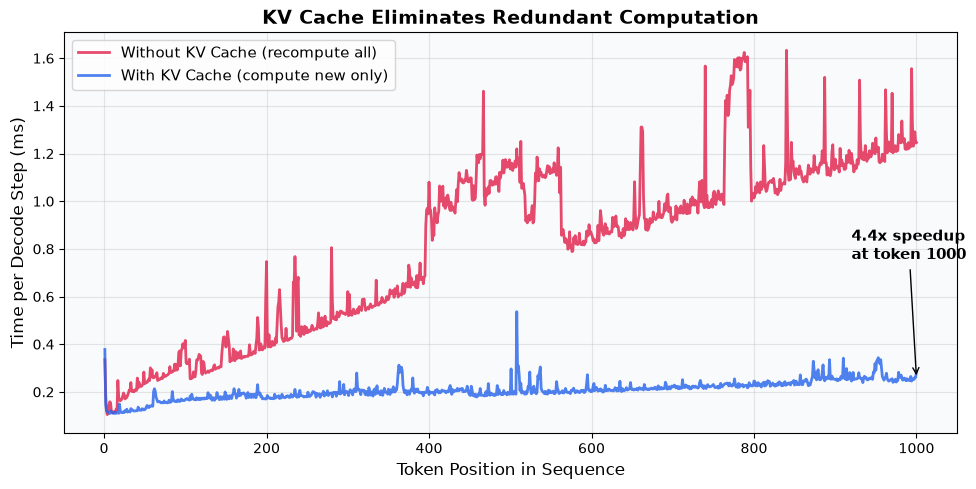

Without cache: O(N) per step -> O(N^2) total for N tokens
With cache:    O(1) projection per step -> O(N) total for N tokens


In [17]:

# Smooth with moving average to reduce CPU measurement noise
window = 10
no_cache_smooth = np.convolve(times_no_cache, np.ones(window)/window, mode="valid")
with_cache_smooth = np.convolve(times_with_cache, np.ones(window)/window, mode="valid")
steps_smooth = range(window, len(times_no_cache) + 1)

# Create the comparison chart
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# X axis: token position (1 to 200)
x = np.arange(1, num_tokens + 1)

# Plot without-cache times (should rise linearly)
ax.plot(x, times_no_cache, color='#e11d48', alpha=0.8,
        linewidth=2, label='Without KV Cache (recompute all)')

# Plot with-cache times (should stay flat)
ax.plot(x, times_with_cache, color='#2563eb', alpha=0.8,
        linewidth=2, label='With KV Cache (compute new only)')

# Annotate the speedup at the last token
speedup = times_no_cache[-1] / max(times_with_cache[-1], 1e-6)
ax.annotate(f'{speedup:.1f}x speedup\nat token {num_tokens}',
            xy=(num_tokens, with_cache_smooth[-1]),
            xytext=(num_tokens - 80, with_cache_smooth[-1] + 0.5),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'))

# Labels and formatting
ax.set_xlabel('Token Position in Sequence', fontsize=12)
ax.set_ylabel('Time per Decode Step (ms)', fontsize=12)
ax.set_title('KV Cache Eliminates Redundant Computation', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.set_facecolor('#f8fafc')  # Light background
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the complexity difference
print(f'Without cache: O(N) per step -> O(N^2) total for N tokens')
print(f'With cache:    O(1) projection per step -> O(N) total for N tokens')

## KV Cache Memory Growth

The cache is not free. For each token in the sequence, we store:
- K vector: `num_layers x num_heads x head_dim x dtype_size` bytes
- V vector: same size

For a typical model (32 layers, 32 heads, 128 head_dim, fp16):
- Per token: 32 layers x 2 (K+V) x 32 heads x 128 dim x 2 bytes = **512 KB per token**

This grows linearly with sequence length and becomes the dominant memory consumer for long contexts.

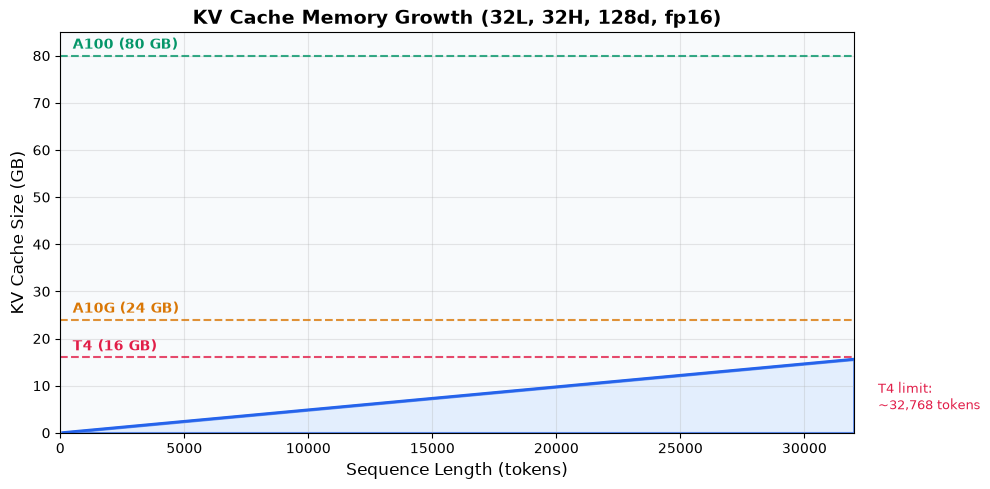

KV cache per token: 512 KB
At 4K tokens:  2.00 GB
At 8K tokens:  4.00 GB
At 32K tokens: 16.00 GB

T4 (16GB) can cache ~32,768 tokens before OOM


In [16]:
# Calculate KV cache memory for various sequence lengths
# Model config: 32 layers, 32 heads, 128 head_dim, fp16 (2 bytes)
bytes_per_token = 32 * 2 * 32 * 128 * 2  # = 524,288 bytes = 512 KB

# Sequence lengths from 100 to 32,000 tokens
seq_lengths = np.arange(100, 32001, 100)

# Cache size in GB for each sequence length
cache_gb = (seq_lengths * bytes_per_token) / (1024**3)

# Create memory growth chart
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Plot cache size vs sequence length
ax.fill_between(seq_lengths, 0, cache_gb,
                color='#dbeafe', alpha=0.7, edgecolor='#2563eb', linewidth=2)
ax.plot(seq_lengths, cache_gb, color='#2563eb', linewidth=2, label='KV Cache Size')

# Horizontal lines for GPU VRAM limits
gpu_limits = [
    (16, 'T4 (16 GB)', '#e11d48'),
    (24, 'A10G (24 GB)', '#d97706'),
    (80, 'A100 (80 GB)', '#059669'),
]
for vram, label, color in gpu_limits:
    ax.axhline(y=vram, linestyle='--', color=color, linewidth=1.5, alpha=0.8)
    ax.text(500, vram + 1.5, label, fontsize=10, color=color, fontweight='bold')

# Find where cache exceeds T4 VRAM
t4_limit_tokens = int(16 * (1024**3) / bytes_per_token)
ax.axvline(x=t4_limit_tokens, linestyle=':', color='#e11d48', alpha=0.5)
ax.text(t4_limit_tokens + 200, 5, f'T4 limit:\n~{t4_limit_tokens:,} tokens',
        fontsize=9, color='#e11d48')

# Labels and formatting
ax.set_xlabel('Sequence Length (tokens)', fontsize=12)
ax.set_ylabel('KV Cache Size (GB)', fontsize=12)
ax.set_title('KV Cache Memory Growth (32L, 32H, 128d, fp16)', fontsize=14, fontweight='bold')
ax.set_facecolor('#f8fafc')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 32000)
ax.set_ylim(0, max(cache_gb[-1] * 1.1, 85))

plt.tight_layout()
plt.show()

# Print key numbers
print(f'KV cache per token: {bytes_per_token / 1024:.0f} KB')
print(f'At 4K tokens:  {4096 * bytes_per_token / (1024**3):.2f} GB')
print(f'At 8K tokens:  {8192 * bytes_per_token / (1024**3):.2f} GB')
print(f'At 32K tokens: {32768 * bytes_per_token / (1024**3):.2f} GB')
print(f'\nT4 (16GB) can cache ~{t4_limit_tokens:,} tokens before OOM')

## Key Takeaways

| Aspect | Without Cache | With Cache |
|--------|-------------|------------|
| K,V computation per step | O(N) projections | O(1) projection |
| Total compute for N tokens | O(N**2) | O(N) |
| Memory cost | None | 512 KB per token per conversation |
| Decode time trend | Rises linearly | Stays constant |

**The fundamental tradeoff:** KV cache trades memory for compute. Every production LLM serving system uses it because the compute savings are enormous (quadratic to linear), but the memory cost becomes the binding constraint for long sequences and large batch sizes.

**What's next:** Module 0.4 connects this to the bigger picture of why LLM inference is expensive, combining the prefill/decode split from 0.2 with the cache dynamics from this lab.